## Project Overview

This project focuses on multi-class classification of breast cancer histopathological images using the BreaKHis dataset. The primary objective is to classify images into 8 different tumor subtypes under the 100X magnification setting.

A ConvNeXt-Tiny architecture is employed as the backbone model due to its strong performance in visual recognition tasks and modern convolutional design.

The training pipeline is implemented in PyTorch, with a focus on:
- Handling class imbalance using WeightedRandomSampler
- Applying data augmentation to improve generalization
- Using transfer learning from ImageNet-pretrained weights
- Optimizing with AdamW and appropriate learning strategies

The final model achieves approximately 92% accuracy, demonstrating strong performance on this classification task.

In [1]:
import os
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
from PIL import Image, ImageFile
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Import required libraries and set up environment
ImageFile.LOAD_TRUNCATED_IMAGES = True

def seed_everything(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

# Stable device selection: CUDA -> MPS -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

pin_memory = device.type == "cuda"
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif device.type == "mps":
    print("Using Apple Metal Performance Shaders (MPS)")

Device: mps
Using Apple Metal Performance Shaders (MPS)


In [2]:
# Define constants and paths

MAG = "100X"
BASE_DIR = Path.cwd()
DATA_ROOT = BASE_DIR / "BreaKHis_v1" / "histology_slides" / "breast"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR : {BASE_DIR}")
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"MAG     : {MAG}")

# More conservative settings for cross-platform stability
BATCH_SIZE = 16 if device.type == "mps" else 32
NUM_EPOCHS = 20
LEARNING_RATE = 3e-5
NUM_WORKERS = 0
WEIGHT_DECAY = 1e-4

print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"LEARNING_RATE: {LEARNING_RATE}")

BASE_DIR : /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1
DATA_ROOT: /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1/BreaKHis_v1/histology_slides/breast
MAG     : 100X
BATCH_SIZE: 16
LEARNING_RATE: 3e-05


In [3]:
# Define class names and mapping

CLASS_NAMES = [
    "adenosis",
    "fibroadenoma",
    "phyllodes_tumor",
    "tubular_adenoma",
    "ductal_carcinoma",
    "lobular_carcinoma",
    "mucinous_carcinoma",
    "papillary_carcinoma"
]

class_to_idx = {cls: i for i, cls in enumerate(CLASS_NAMES)}


## Dataset and Preprocessing

The dataset is organized in a hierarchical folder structure:
BreaKHis_v1/histology_slides/breast/[benign|malignant]/...

Only images with 100X magnification are selected for consistency.

Each image is:
- Loaded using PIL
- Resized and cropped to match model input size (224x224)
- Augmented using random transformations (flip, crop)
- Normalized using ImageNet mean and standard deviation

Normalization is critical because the ConvNeXt model was pretrained on ImageNet.

In [4]:
# Load dataset and prepare samples

def load_breakhis(magnification: str = "100X"):
    samples = []
    magnification = magnification.upper()

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"Dataset root not found: {DATA_ROOT}")

    for img_path in DATA_ROOT.rglob("*.png"):
        if img_path.parent.name.upper() != magnification:
            continue

        parts = set(img_path.parts)
        cls = next((name for name in CLASS_NAMES if name in parts), None)
        if cls is None:
            continue

        label = class_to_idx[cls]
        samples.append((str(img_path), label))

    return sorted(samples)


In [5]:
# Define custom Dataset class

class BreakHisDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            with Image.open(img_path) as img:
                img = img.convert("RGB")
                if self.transform is not None:
                    img = self.transform(img)
            return img, torch.tensor(label, dtype=torch.long)
        except Exception as exc:
            raise RuntimeError(f"Failed to load image: {img_path}") from exc


In [6]:
# Define data transformations

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Keep augmentation moderate for better stability across CUDA/MPS
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [7]:
# Load dataset and split into train/val/test sets

full_samples = load_breakhis(MAG)
if not full_samples:
    raise ValueError(f"No samples found for magnification={MAG}. Check DATA_ROOT and folder names.")

labels = [s[1] for s in full_samples]
print(f"Total samples: {len(full_samples)}")
print("Full distribution:", Counter(labels))

# Stratified split to maintain class distribution across train/val/test sets
train_samples, temp_samples = train_test_split(
    full_samples,
    test_size=0.30,
    stratify=labels,
    random_state=42,
)

val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.50,
    stratify=[s[1] for s in temp_samples],
    random_state=42,
)

# Print dataset statistics
print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")
print("Train distribution:", Counter([s[1] for s in train_samples]))
print("Val distribution  :", Counter([s[1] for s in val_samples]))
print("Test distribution :", Counter([s[1] for s in test_samples]))

# Save split information for reproducibility
split_info = {
    "mag": MAG,
    "class_names": CLASS_NAMES,
    "class_to_idx": class_to_idx,
    "train_samples": train_samples,
    "val_samples": val_samples,
    "test_samples": test_samples,
}
split_path = MODEL_DIR / f"split_info_{MAG}.json"
with open(split_path, "w", encoding="utf-8") as f:
    json.dump(split_info, f, ensure_ascii=False, indent=2)
print(f"Saved split info to: {split_path}")

Total samples: 2081
Full distribution: Counter({4: 903, 1: 260, 6: 222, 5: 170, 3: 150, 7: 142, 2: 121, 0: 113})
Train: 1456 | Val: 312 | Test: 313
Train distribution: Counter({4: 632, 1: 182, 6: 155, 5: 119, 3: 105, 7: 99, 2: 85, 0: 79})
Val distribution  : Counter({4: 135, 1: 39, 6: 33, 5: 25, 3: 23, 7: 22, 2: 18, 0: 17})
Test distribution : Counter({4: 136, 1: 39, 6: 34, 5: 26, 3: 22, 7: 21, 2: 18, 0: 17})
Saved split info to: /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1/models/split_info_100X.json


## Stable Training Configuration
This version removes weighted sampling and aggressive scheduling to improve cross-platform stability on both CUDA and MPS. Reproducibility artifacts such as split information are also saved.

In [8]:
# Create datasets
train_ds = BreakHisDataset(train_samples, train_tf)
val_ds = BreakHisDataset(val_samples, test_tf)
test_ds = BreakHisDataset(test_samples, test_tf)

print("Train dataset size:", len(train_ds))
print("Val dataset size  :", len(val_ds))
print("Test dataset size :", len(test_ds))

Train dataset size: 1456
Val dataset size  : 312
Test dataset size : 313


In [9]:
# Create DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

## Model Architecture

The model is based on ConvNeXt-Tiny, a modern convolutional neural network architecture inspired by Vision Transformers.

Key design choices:
- Pretrained weights (ImageNet) are used for transfer learning
- The final classification head is replaced to match the number of classes (8)
- Only the classifier layer is trained initially, while the backbone remains frozen

This approach allows the model to leverage learned visual features while adapting to the medical classification task.

In [10]:
# Create model, modify classifier for our number of classes, and move to device
model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, len(CLASS_NAMES))
model = model.to(device)

print(f"Classifier out_features: {model.classifier[2].out_features}")


Classifier out_features: 8


## Optimization Strategy

The model is trained using the AdamW optimizer, which is well-suited for modern deep learning architectures.

Key components:
- Learning rate: 1e-4
- Weight decay is applied to prevent overfitting
- Loss function: CrossEntropyLoss

AdamW is preferred over standard Adam because it decouples weight decay from gradient updates, leading to better generalization.

In [11]:
# Define loss function, optimizer, and learning rate scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [12]:
# Function to calculate evaluation metrics
def calculate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return acc, p, r, f

best_f1 = 0.0
best_model_path = MODEL_DIR / f"best_convnext_tiny_{MAG.lower()}.pth"


## Training Process

During training:
- The model processes mini-batches of images
- Loss is computed using cross-entropy
- Gradients are backpropagated
- Model weights are updated using the optimizer

Validation is performed at the end of each epoch to monitor generalization performance.

The best model is saved based on validation accuracy.

In [13]:
# Training loop with validation and model checkpointing
print(f"{'Epoch':^6} | {'Train Loss':^10} | {'Val Loss':^10} | {'Val Acc':^9} | {'Val Prec':^9} | {'Val Rec':^9} | {'Val F1':^9} | {'LR':^10} | {'Status'}")
print("-" * 115)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
        imgs = imgs.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc, val_prec, val_rec, val_f1 = calculate_metrics(y_true, y_pred)
    scheduler.step(val_f1)

    current_lr = optimizer.param_groups[0]["lr"]
    status = ""

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": CLASS_NAMES,
                "class_to_idx": class_to_idx,
                "mag": MAG,
            },
            best_model_path,
        )
        status = "⭐ BEST"

    print(
        f"{epoch:^6} | {avg_train_loss:^10.4f} | {avg_val_loss:^10.4f} | "
        f"{val_acc * 100:^8.2f}% | {val_prec * 100:^8.2f}% | "
        f"{val_rec * 100:^8.2f}% | {val_f1 * 100:^8.2f}% | {current_lr:^10.2e} | {status}"
    )

Epoch  | Train Loss |  Val Loss  |  Val Acc  | Val Prec  |  Val Rec  |  Val F1   |     LR     | Status
-------------------------------------------------------------------------------------------------------------------


Epoch 1:   0%|          | 0/91 [00:00<?, ?it/s]

  1    |   1.4472   |   1.0371   |  61.54  % |  74.29  % |  37.43  % |  38.34  % |  3.00e-05  | ⭐ BEST


Epoch 2:   0%|          | 0/91 [00:00<?, ?it/s]

  2    |   0.8441   |   0.5991   |  80.13  % |  80.53  % |  70.90  % |  74.00  % |  3.00e-05  | ⭐ BEST


...

  18   |   0.0409   |   0.1686   |  93.59  % |  94.83  % |  92.33  % |  93.48  % |  7.50e-06  | 


Epoch 19:   0%|          | 0/91 [00:00<?, ?it/s]

  19   |   0.0430   |   0.1676   |  93.59  % |  94.35  % |  91.70  % |  92.95  % |  3.75e-06  | 


Epoch 20:   0%|          | 0/91 [00:00<?, ?it/s]

  20   |   0.0410   |   0.1525   |  95.51  % |  95.42  % |  94.97  % |  95.14  % |  3.75e-06  | ⭐ BEST


## Evaluation

The model is evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Accuracy provides a general overview, while F1-score gives better insight into performance under class imbalance.

Confusion matrix helps identify which classes are frequently misclassified.

In [14]:
# After training, print best validation F1 score and load the best model for final evaluation on the test set.
print(f"Best validation macro F1: {best_f1:.4f}")
print(f"Best model saved to: {best_model_path}")

checkpoint = torch.load(best_model_path, map_location=device)
print("Checkpoint keys:", checkpoint.keys())
print("Saved class_to_idx:", checkpoint.get("class_to_idx"))

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_loss = 0.0
y_true = []
y_pred = []

# Evaluate on test set using the best model
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_acc, test_prec, test_rec, test_f1 = calculate_metrics(y_true, y_pred)

Best validation macro F1: 0.9514
Best model saved to: /Users/sarpustacom/03_ASIL_Lab/Assignments_Courses/BreastCancerV1/models/best_convnext_tiny_100x.pth
Checkpoint keys: dict_keys(['model_state_dict', 'class_names', 'class_to_idx', 'mag'])
Saved class_to_idx: {'adenosis': 0, 'fibroadenoma': 1, 'phyllodes_tumor': 2, 'tubular_adenoma': 3, 'ductal_carcinoma': 4, 'lobular_carcinoma': 5, 'mucinous_carcinoma': 6, 'papillary_carcinoma': 7}


TEST RESULTS
------------------------------------------------------------
Test Loss      : 0.1430
Test Accuracy  : 0.9457
Test Precision : 0.9486
Test Recall    : 0.9356
Test Macro F1  : 0.9415

Classification Report:
                     precision    recall  f1-score   support

           adenosis       1.00      0.88      0.94        17
       fibroadenoma       0.97      1.00      0.99        39
    phyllodes_tumor       1.00      1.00      1.00        18
    tubular_adenoma       0.95      0.95      0.95        22
   ductal_carcinoma       0.95      0.96      0.95       136
  lobular_carcinoma       0.85      0.85      0.85        26
 mucinous_carcinoma       0.91      0.94      0.93        34
papillary_carcinoma       0.95      0.90      0.93        21

           accuracy                           0.95       313
          macro avg       0.95      0.94      0.94       313
       weighted avg       0.95      0.95      0.95       313

Confusion Matrix:
[[ 15   0   0   0   0   0   2

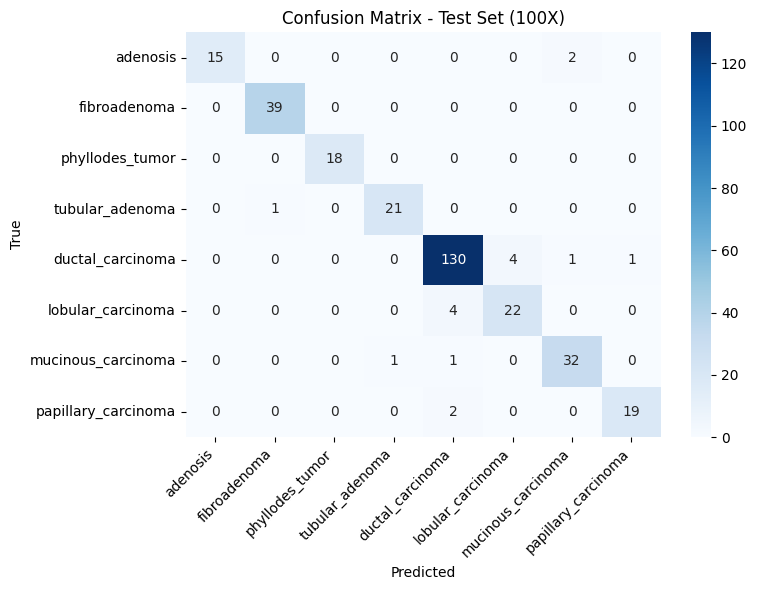

In [15]:
# Gerekli kütüphanelerin import edildiğinden emin olalım
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Print final test results and classification report
print("TEST RESULTS")
print("-" * 60)
print(f"Test Loss      : {avg_test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test Macro F1  : {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Confusion Matrix Görselleştirmesi
plt.figure(figsize=(8, 6))

# Sadece Seaborn Heatmap kullanarak temiz bir görünüm elde ediyoruz
sns.heatmap(cm, 
            annot=True,           # Hücrelerin içine sayıları otomatik yazdırır
            fmt="d",              # Sayıların tam sayı (integer) formatında olmasını sağlar
            cmap="Blues",         # "blues" yerine "Blues" olmalı
            xticklabels=CLASS_NAMES, 
            yticklabels=CLASS_NAMES)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)            # Y eksenindeki isimlerin düz okunmasını sağlar
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - Test Set ({MAG})")

plt.tight_layout()
plt.show()

## Results and Conclusion
This notebook uses a more stable cross-platform training setup for PyTorch on both CUDA and MPS. The focus is not maximum aggressiveness, but reproducibility, cleaner optimization behavior, and more trustworthy validation/test results.